# 🛒 Shopper Spectrum:
## Customer Segmentation and Product Recommendation in E-Commerce

### **Submitted By**
**Name:** Rabiya Khanum

### **Project Overview**
This project analyzes an online retail transaction dataset to understand customer purchasing behavior. It performs customer segmentation using RFM Analysis and K-Means Clustering and builds a product recommendation system using Item-Based Collaborative Filtering. The goal is to help businesses identify valuable customer groups and recommend similar products to improve customer satisfaction and sales.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ==========================================
# Load the Dataset
# ==========================================

df = pd.read_csv("online_retail.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# Display the first 5 rows

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Dataset Information

print("Shape of Dataset:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (541909, 8)

Column Names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Data Cleaning

In this step, we clean the dataset by handling missing values, removing invalid transactions, converting data types, and eliminating duplicate records. This improves data quality before analysis and machine learning.

In [5]:
# ==========================================
# Data Cleaning
# ==========================================

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled invoices (Invoice numbers starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove invalid Quantity
df = df[df['Quantity'] > 0]

# Remove invalid UnitPrice
df = df[df['UnitPrice'] > 0]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove duplicate rows
df = df.drop_duplicates()

print("\nData Cleaning Completed Successfully!")

print("\nNew Shape of Dataset:", df.shape)

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Data Cleaning Completed Successfully!

New Shape of Dataset: (392692, 8)


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand customer purchasing behavior, identify trends, detect patterns, and gain business insights before applying machine learning algorithms.

In [6]:
# ==========================================
# Feature Engineering
# ==========================================

# Create Total Amount column

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("Feature Created Successfully!")

df.head()

Feature Created Successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Graph 1: Top 10 Countries by Total Sales

This chart shows the top 10 countries based on total sales amount. It helps identify the countries that contribute the most to the business revenue.

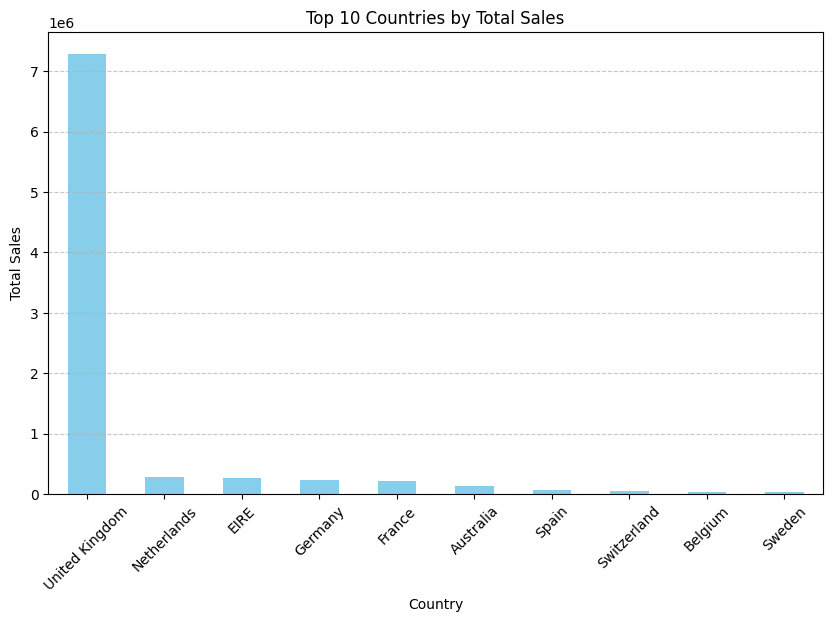

In [7]:
# ==========================================
# Top 10 Countries by Total Sales
# ==========================================

country_sales = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
country_sales.plot(kind='bar', color='skyblue')

plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Graph 2: Top 10 Best-Selling Products

This graph displays the top 10 products based on the total quantity sold.

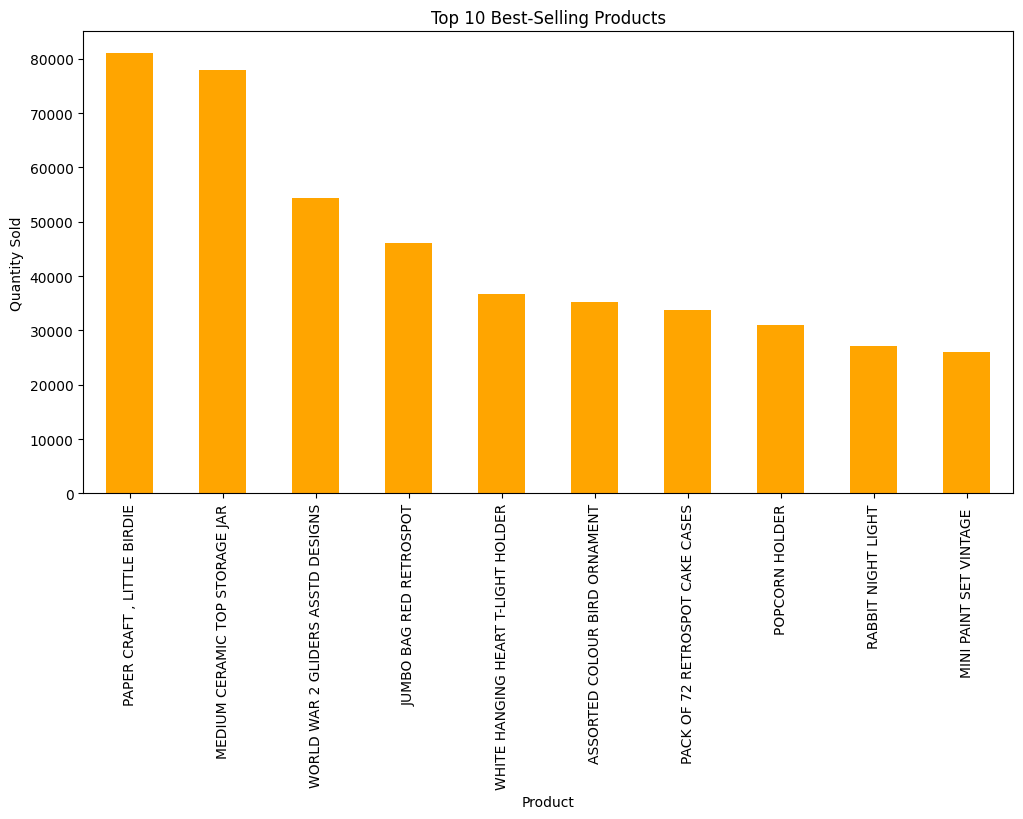

In [8]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar', color='orange')

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=90)

plt.show()

## Graph 3: Monthly Sales Trend

This graph shows how sales changed across different months.

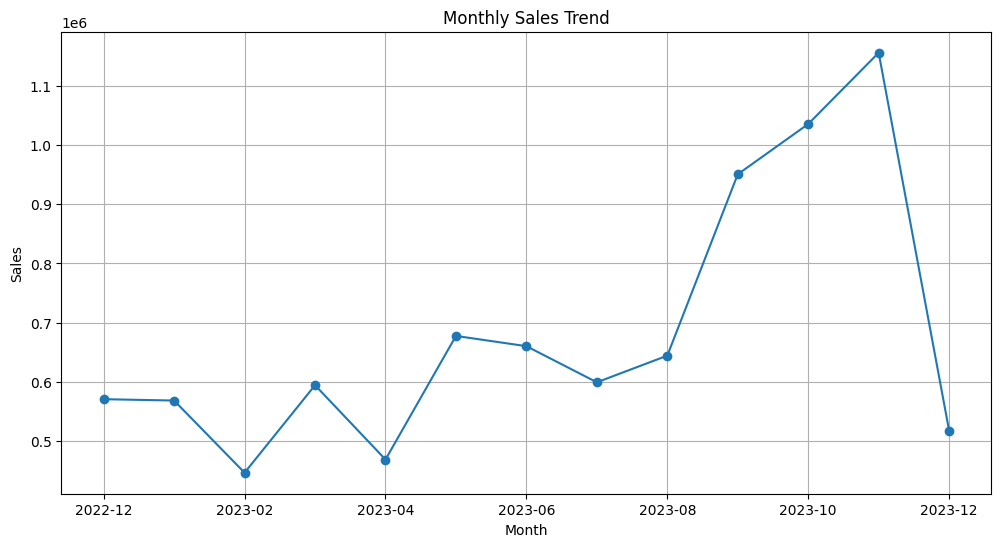

In [9]:
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('Month')['TotalAmount'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.grid(True)
plt.show()

## Graph 4: Revenue Distribution

This histogram shows the distribution of transaction amounts.

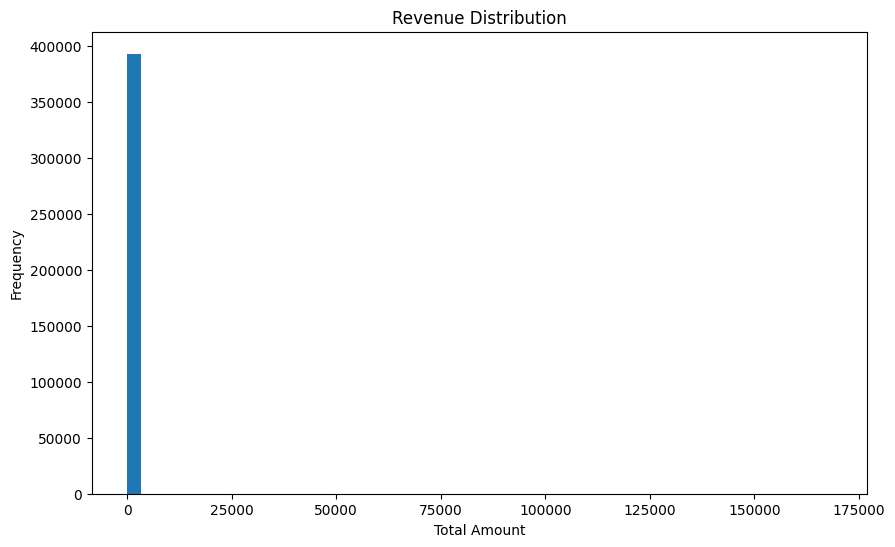

In [10]:
plt.figure(figsize=(10,6))

plt.hist(df['TotalAmount'], bins=50)

plt.title('Revenue Distribution')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')

plt.show()

## Graph 5: Top Customers by Spending

This graph identifies customers who contributed the highest revenue.

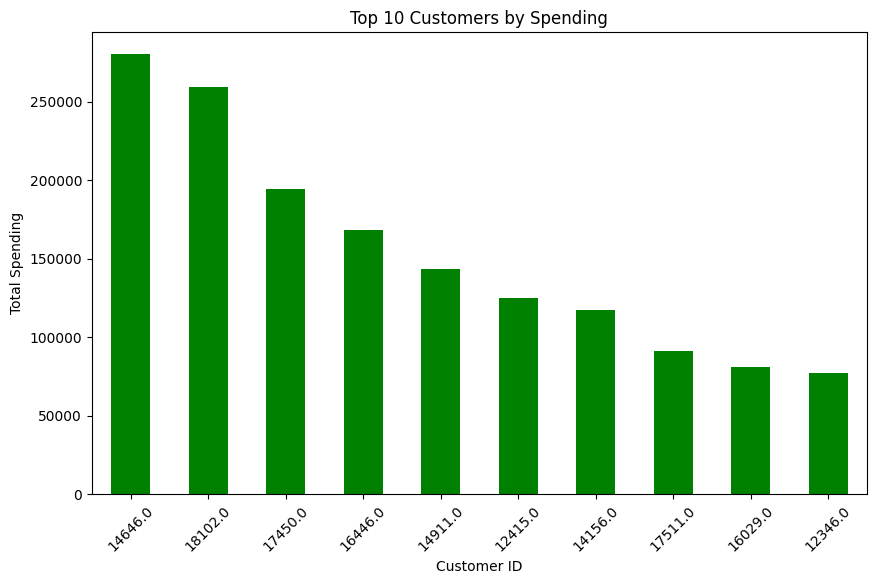

In [11]:
top_customers = df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_customers.plot(kind='bar', color='green')

plt.title('Top 10 Customers by Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending')

plt.xticks(rotation=45)

plt.show()

# RFM Analysis

RFM (Recency, Frequency, Monetary) analysis is used to understand customer purchasing behavior.

- **Recency (R):** Number of days since the customer's last purchase.
- **Frequency (F):** Number of unique purchases made by the customer.
- **Monetary (M):** Total amount spent by the customer.

These features will be used for customer segmentation using K-Means clustering.

In [12]:
# ==========================================
# RFM Analysis
# ==========================================

# Latest purchase date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM Table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

# Rename Columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Display first 5 rows
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## RFM Summary Statistics

In [13]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


## Feature Scaling

Since Recency, Frequency, and Monetary have different ranges, we standardize them before applying K-Means clustering.

In [14]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print("Scaling Completed Successfully!")

Scaling Completed Successfully!


## Elbow Method

The Elbow Method helps determine the optimal number of clusters (K) for K-Means.

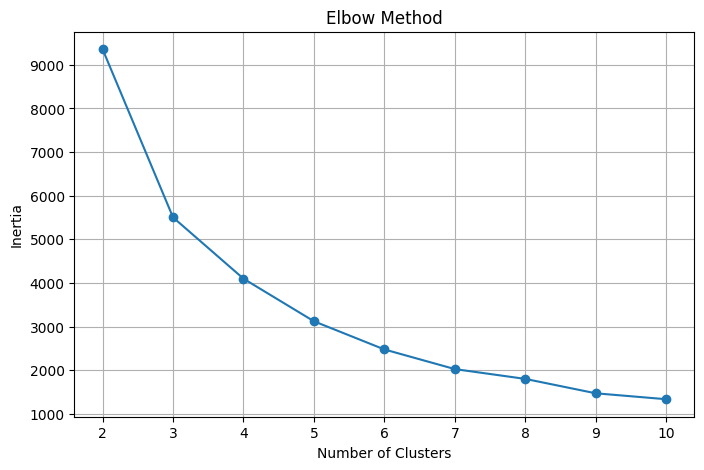

In [15]:
inertia = []

for k in range(2,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(True)
plt.show()

## Silhouette Score

The Silhouette Score measures how well-separated the clusters are. A higher score indicates better clustering quality.

In [16]:
# ==========================================
# Silhouette Score
# ==========================================

kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(rfm_scaled)

score = silhouette_score(rfm_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.6162275299061803


## Customer Segmentation using K-Means

In [17]:
rfm['Cluster'] = clusters

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


## Cluster Analysis

The average values of Recency, Frequency, and Monetary for each customer cluster are displayed below.

In [18]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


## Customer Cluster Visualization

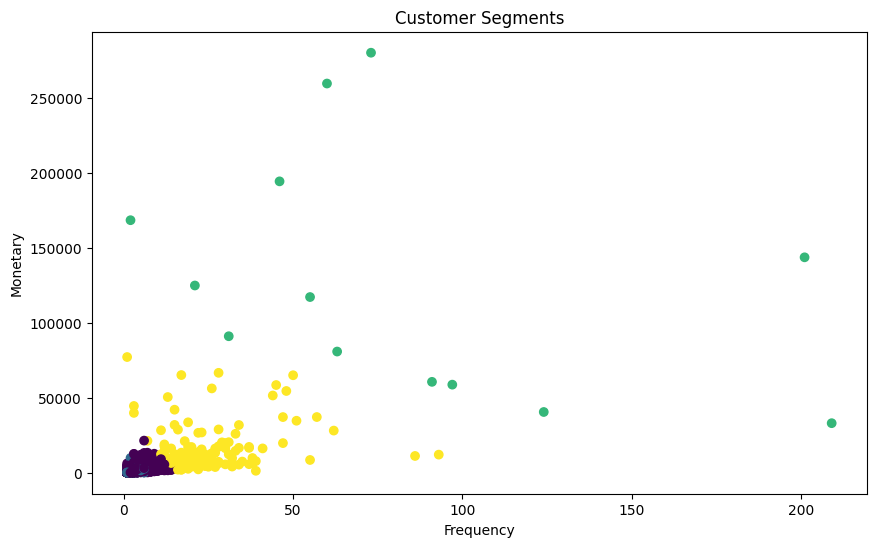

In [19]:
plt.figure(figsize=(10,6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis'
)

plt.title("Customer Segments")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

# Product Recommendation System

This section builds an Item-Based Collaborative Filtering recommendation system using cosine similarity.

In [20]:
# ==========================================
# Product Recommendation
# ==========================================

product_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    fill_value=0
)

product_similarity = cosine_similarity(product_matrix.T)

similarity_df = pd.DataFrame(
    product_similarity,
    index=product_matrix.columns,
    columns=product_matrix.columns
)

print("Recommendation Model Created Successfully!")

Recommendation Model Created Successfully!


In [21]:
def recommend_products(product_name, top_n=5):

    if product_name not in similarity_df.index:
        return "Product not found."

    recommendations = similarity_df[product_name].sort_values(ascending=False)[1:top_n+1]

    return recommendations

In [22]:
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")

,WHITE HANGING HEART T-LIGHT HOLDER
Description,
GIN + TONIC DIET METAL SIGN,0.935865
TEA TIME TEA TOWELS,0.925193
FAIRY CAKE FLANNEL ASSORTED COLOUR,0.914906
DOORMAT FAIRY CAKE,0.888526
RED HANGING HEART T-LIGHT HOLDER,0.258615


In [23]:
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")

,WHITE HANGING HEART T-LIGHT HOLDER
Description,
GIN + TONIC DIET METAL SIGN,0.935865
TEA TIME TEA TOWELS,0.925193
FAIRY CAKE FLANNEL ASSORTED COLOUR,0.914906
DOORMAT FAIRY CAKE,0.888526
RED HANGING HEART T-LIGHT HOLDER,0.258615


In [24]:
import joblib

# Save KMeans Model
joblib.dump(kmeans, "kmeans_model.pkl")

# Save StandardScaler
joblib.dump(scaler, "scaler.pkl")

# Save Product Similarity Matrix
joblib.dump(similarity_df, "product_similarity.pkl")

print("All models saved successfully!")

All models saved successfully!


# Conclusion

In this project, customer transaction data was analyzed to understand purchasing behavior. Data cleaning and exploratory data analysis were performed to gain business insights. RFM analysis and K-Means clustering were used to segment customers into meaningful groups. An item-based collaborative filtering recommendation system was also developed to suggest similar products. This project demonstrates how machine learning can help businesses improve customer engagement, marketing strategies, and product recommendations.